In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Plot style
sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")


Matplotlib is building the font cache; this may take a moment.


Libraries imported successfully!


In [2]:
DATA_PATH = Path("../data/raw")

fraud_path = DATA_PATH / "Fraud_Data.csv"
credit_path = DATA_PATH / "creditcard.csv"
country_path = DATA_PATH / "IpAddress_to_Country.csv"

In [3]:
fraud_df = pd.read_csv(fraud_path)

credit_df = pd.read_csv(credit_path)

country_df = pd.read_csv(country_path)

In [4]:
print(fraud_df.shape)
print(credit_df.shape)
print(country_df.shape)

(151112, 11)
(284807, 31)
(138846, 3)


In [5]:
fraud_df.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


In [6]:
credit_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [7]:
country_df.head()

,lower_bound_ip_address,upper_bound_ip_address,country
0,16777216.0,16777471,Australia
1,16777472.0,16777727,China
2,16777728.0,16778239,China
3,16778240.0,16779263,Australia
4,16779264.0,16781311,China


In [8]:
fraud_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   user_id         151112 non-null  int64  
 1   signup_time     151112 non-null  str    
 2   purchase_time   151112 non-null  str    
 3   purchase_value  151112 non-null  int64  
 4   device_id       151112 non-null  str    
 5   source          151112 non-null  str    
 6   browser         151112 non-null  str    
 7   sex             151112 non-null  str    
 8   age             151112 non-null  int64  
 9   ip_address      151112 non-null  float64
 10  class           151112 non-null  int64  
dtypes: float64(1), int64(4), str(6)
memory usage: 12.7 MB


In [9]:
fraud_df.describe(include="all")

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
count,151112.000000,151112,151112,151112.000000,151112,151112,151112,151112,151112.000000,1.511120e+05,151112.000000
unique,NaN,151112,150679,NaN,137956,3,5,2,NaN,NaN,NaN
top,NaN,2015-02-24 22:55:49,2015-07-17 23:22:55,NaN,ITUMJCKWEYNDD,SEO,Chrome,M,NaN,NaN,NaN
freq,NaN,1,3,NaN,20,60615,61432,88293,NaN,NaN,NaN
mean,200171.040970,NaN,NaN,36.935372,NaN,NaN,NaN,NaN,33.140704,2.152145e+09,0.093646
std,115369.285024,NaN,NaN,18.322762,NaN,NaN,NaN,NaN,8.617733,1.248497e+09,0.291336
min,2.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,18.000000,5.209350e+04,0.000000
25%,100642.500000,NaN,NaN,22.000000,NaN,NaN,NaN,NaN,27.000000,1.085934e+09,0.000000
50%,199958.000000,NaN,NaN,35.000000,NaN,NaN,NaN,NaN,33.000000,2.154770e+09,0.000000
75%,300054.000000,NaN,NaN,49.000000,NaN,NaN,NaN,NaN,39.000000,3.243258e+09,0.000000


In [10]:
credit_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [11]:
credit_df.describe(include="all")

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,2.238554e-15,1.724421e-15,-1.245415e-15,8.238900e-16,1.213481e-15,4.866699e-15,1.436219e-15,-3.768179e-16,9.707851e-16,1.036249e-15,6.418678e-16,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,1.088850e+00,1.020713e+00,9.992014e-01,9.952742e-01,9.585956e-01,9.153160e-01,8.762529e-01,8.493371e-01,8.381762e-01,8.140405e-01,7.709250e-01,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,-2.458826e+01,-4.797473e+00,-1.868371e+01,-5.791881e+00,-1.921433e+01,-4.498945e+00,-1.412985e+01,-2.516280e+01,-9.498746e+00,-7.213527e+00,-5.449772e+01,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,-5.354257e-01,-7.624942e-01,-4.055715e-01,-6.485393e-01,-4.255740e-01,-5.828843e-01,-4.680368e-01,-4.837483e-01,-4.988498e-01,-4.562989e-01,-2.117214e-01,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,-9.291738e-02,-3.275735e-02,1.400326e-01,-1.356806e-02,5.060132e-02,4.807155e-02,6.641332e-02,-6.567575e-02,-3.636312e-03,3.734823e-03,-6.248109e-02,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,4.539234e-01,7.395934e-01,6.182380e-01,6.625050e-01,4.931498e-01,6.488208e-01,5.232963e-01,3.996750e-01,5.008067e-01,4.589494e-01,1.330408e-01,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,2.374514e+01,1.201891e+01,7.848392e+00,7.126883e+00,1.052677e+01,8.877742e+00,1.731511e+01,9.253526e+00,5.041069e+00,5.591971e+00,3.942090e+01,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [12]:
country_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 138846 entries, 0 to 138845
Data columns (total 3 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   lower_bound_ip_address  138846 non-null  float64
 1   upper_bound_ip_address  138846 non-null  int64  
 2   country                 138846 non-null  str    
dtypes: float64(1), int64(1), str(1)
memory usage: 3.2 MB


In [13]:
country_df.describe(include="all")

,lower_bound_ip_address,upper_bound_ip_address,country
count,1.388460e+05,1.388460e+05,138846
unique,NaN,NaN,235
top,NaN,NaN,United States
freq,NaN,NaN,46868
mean,2.724532e+09,2.724557e+09,NaN
std,8.975215e+08,8.974979e+08,NaN
min,1.677722e+07,1.677747e+07,NaN
25%,1.919930e+09,1.920008e+09,NaN
50%,3.230887e+09,3.230888e+09,NaN
75%,3.350465e+09,3.350466e+09,NaN


In [14]:
fraud_df.isnull().sum()

user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64

In [15]:
missing = fraud_df.isnull().sum()

missing[missing > 0]

Series([], dtype: int64)

In [16]:
missing = credit_df.isnull().sum()

missing[missing > 0]

Series([], dtype: int64)

In [17]:
missing = country_df.isnull().sum()

missing[missing > 0]

Series([], dtype: int64)

In [18]:
fraud_df.duplicated().sum()

np.int64(0)

In [19]:
credit_df.duplicated().sum()

np.int64(1081)

### Duplicate Records Analysis

The dataset was checked for duplicate transactions. A total of 1,081 duplicate records were identified.

Duplicate records can affect model performance by causing the model to learn repeated patterns and potentially bias evaluation results. These records should be removed before model training.

In [21]:
country_df.duplicated().sum()

np.int64(0)

In [22]:
credit_df = credit_df.drop_duplicates()

In [23]:
credit_df.duplicated().sum()

np.int64(0)

In [24]:
fraud_df["signup_time"] = pd.to_datetime(fraud_df["signup_time"])

fraud_df["purchase_time"] = pd.to_datetime(fraud_df["purchase_time"])

In [25]:
fraud_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   user_id         151112 non-null  int64         
 1   signup_time     151112 non-null  datetime64[us]
 2   purchase_time   151112 non-null  datetime64[us]
 3   purchase_value  151112 non-null  int64         
 4   device_id       151112 non-null  str           
 5   source          151112 non-null  str           
 6   browser         151112 non-null  str           
 7   sex             151112 non-null  str           
 8   age             151112 non-null  int64         
 9   ip_address      151112 non-null  float64       
 10  class           151112 non-null  int64         
dtypes: datetime64[us](2), float64(1), int64(4), str(4)
memory usage: 12.7 MB


In [27]:
fraud_df['signup_time'] = pd.to_datetime(fraud_df['signup_time']).astype('datetime64[ns]')
fraud_df['purchase_time'] = pd.to_datetime(fraud_df['purchase_time']).astype('datetime64[ns]')

In [28]:
fraud_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   user_id         151112 non-null  int64         
 1   signup_time     151112 non-null  datetime64[ns]
 2   purchase_time   151112 non-null  datetime64[ns]
 3   purchase_value  151112 non-null  int64         
 4   device_id       151112 non-null  str           
 5   source          151112 non-null  str           
 6   browser         151112 non-null  str           
 7   sex             151112 non-null  str           
 8   age             151112 non-null  int64         
 9   ip_address      151112 non-null  float64       
 10  class           151112 non-null  int64         
dtypes: datetime64[ns](2), float64(1), int64(4), str(4)
memory usage: 12.7 MB


In [29]:
fraud_df["class"].value_counts()

class
0    136961
1     14151
Name: count, dtype: int64

In [30]:
fraud_df["class"].value_counts(normalize=True) * 100

class
0    90.635423
1     9.364577
Name: proportion, dtype: float64

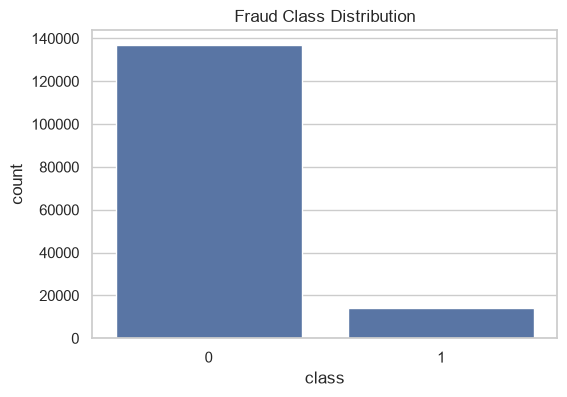

In [31]:
plt.figure(figsize=(6,4))

sns.countplot(data=fraud_df, x="class")

plt.title("Fraud Class Distribution")

plt.show()

In [32]:
credit_df["Class"].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

In [33]:
credit_df["Class"].value_counts(normalize=True) * 100

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64

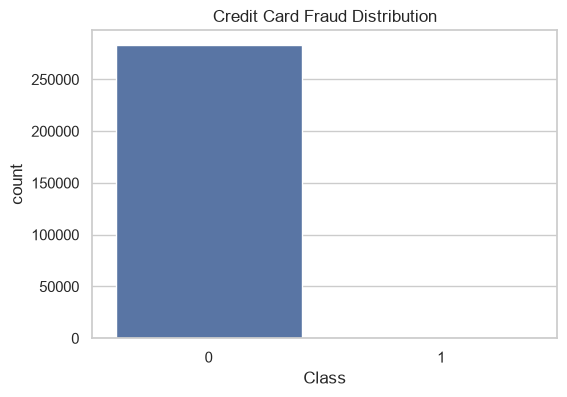

In [34]:
plt.figure(figsize=(6,4))

sns.countplot(data=credit_df, x="Class")

plt.title("Credit Card Fraud Distribution")

plt.show()

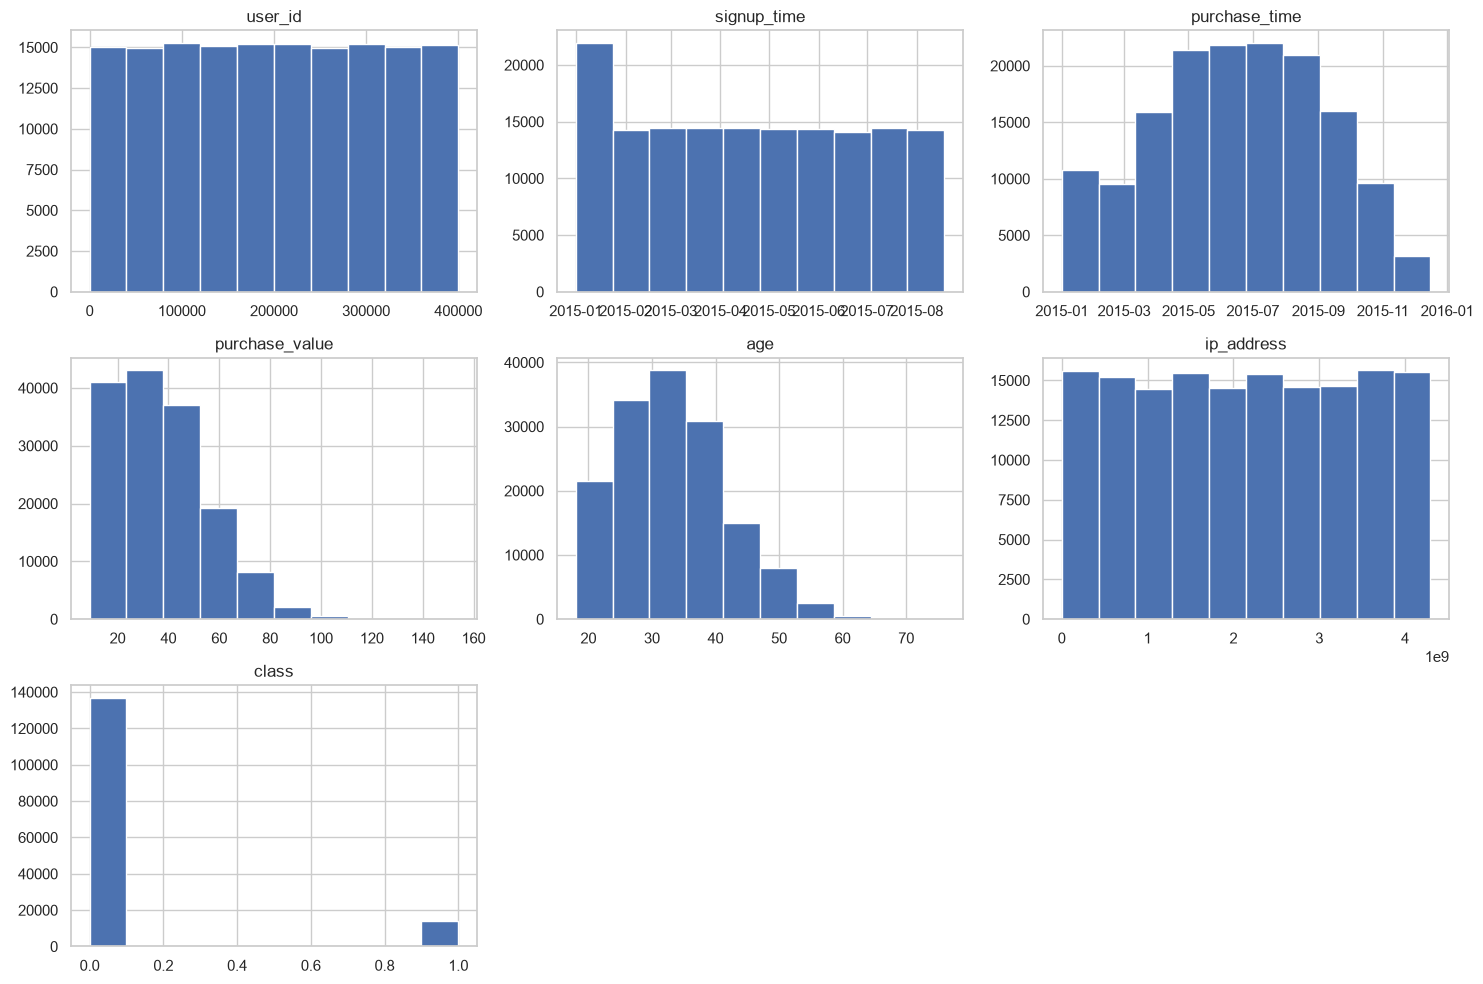

In [35]:
fraud_df.hist(figsize=(15,10))

plt.tight_layout()

plt.show()

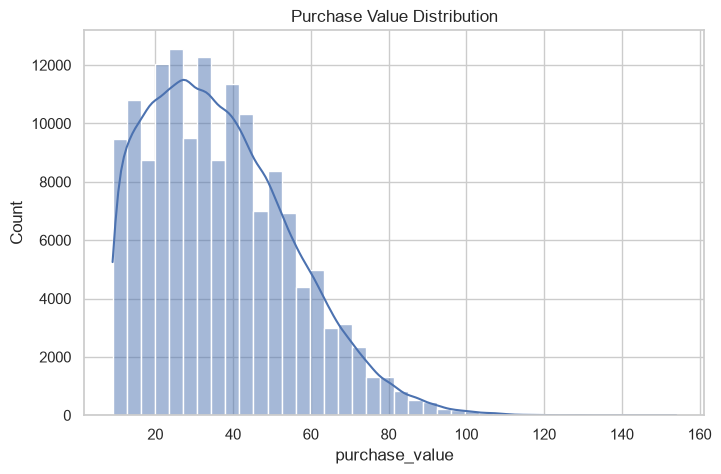

In [36]:
plt.figure(figsize=(8,5))

sns.histplot(
    fraud_df["purchase_value"],
    bins=40,
    kde=True
)

plt.title("Purchase Value Distribution")

plt.show()

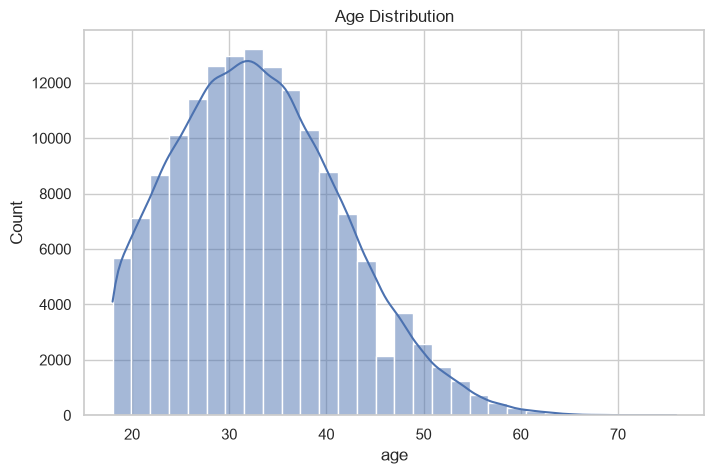

In [37]:
plt.figure(figsize=(8,5))

sns.histplot(
    fraud_df["age"],
    bins=30,
    kde=True
)

plt.title("Age Distribution")

plt.show()

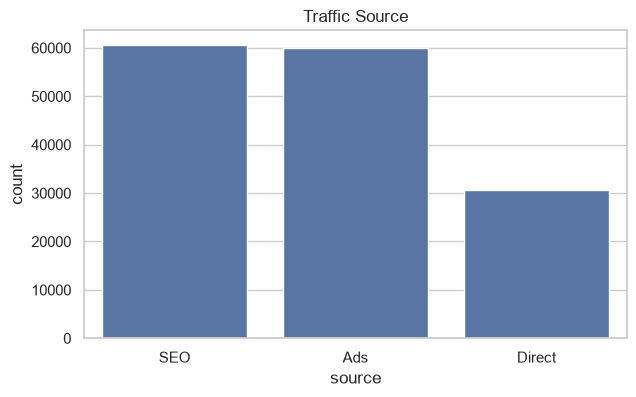

In [38]:
plt.figure(figsize=(7,4))

sns.countplot(data=fraud_df, x="source")

plt.title("Traffic Source")

plt.show()

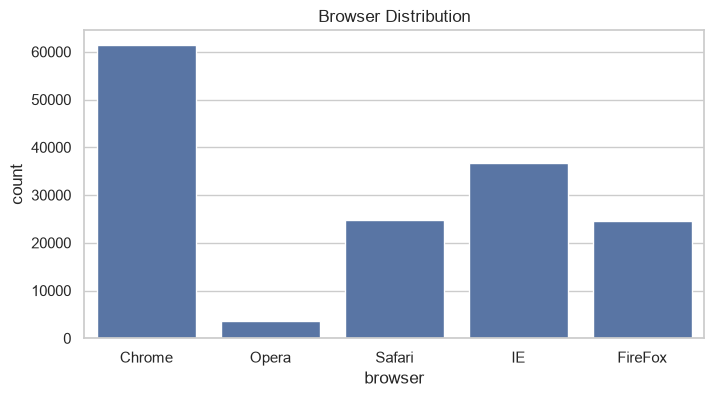

In [39]:
plt.figure(figsize=(8,4))

sns.countplot(data=fraud_df, x="browser")

plt.title("Browser Distribution")

plt.show()

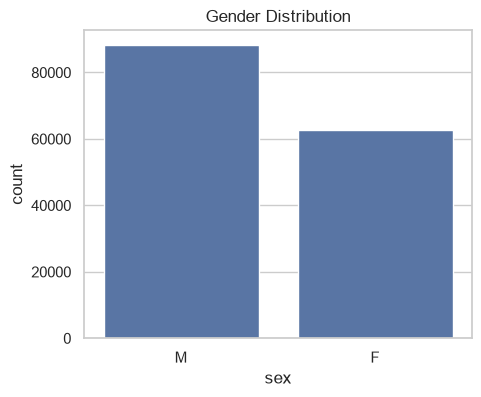

In [40]:
plt.figure(figsize=(5,4))

sns.countplot(data=fraud_df, x="sex")

plt.title("Gender Distribution")

plt.show()

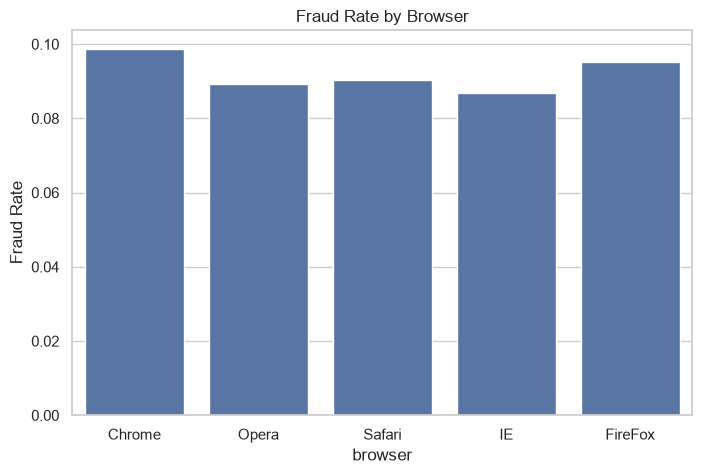

In [41]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=fraud_df,
    x="browser",
    y="class",
    estimator="mean",
    errorbar=None
)

plt.title("Fraud Rate by Browser")
plt.ylabel("Fraud Rate")

plt.show()

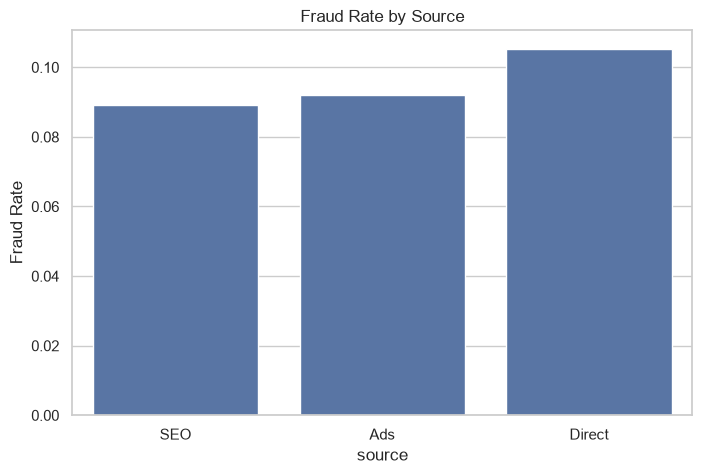

In [42]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=fraud_df,
    x="source",
    y="class",
    estimator="mean",
    errorbar=None
)

plt.title("Fraud Rate by Source")
plt.ylabel("Fraud Rate")

plt.show()

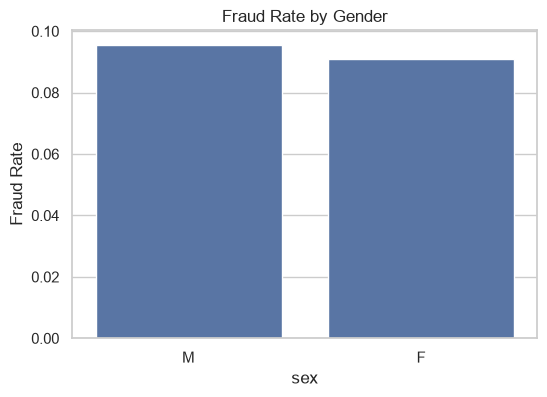

In [43]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=fraud_df,
    x="sex",
    y="class",
    estimator="mean",
    errorbar=None
)

plt.title("Fraud Rate by Gender")
plt.ylabel("Fraud Rate")

plt.show()

In [44]:
import ipaddress

In [45]:
def ip_to_int(ip):
    try:
        return int(ipaddress.ip_address(ip))
    except:
        return np.nan

In [46]:
fraud_df["ip_address_int"] = fraud_df["ip_address"].apply(ip_to_int)

In [47]:
fraud_df[["ip_address","ip_address_int"]].head()

,ip_address,ip_address_int
0,7.327584e+08,NaN
1,3.503114e+08,NaN
2,2.621474e+09,NaN
3,3.840542e+09,NaN
4,4.155831e+08,NaN


In [48]:
country_df.head()

,lower_bound_ip_address,upper_bound_ip_address,country
0,16777216.0,16777471,Australia
1,16777472.0,16777727,China
2,16777728.0,16778239,China
3,16778240.0,16779263,Australia
4,16779264.0,16781311,China


In [49]:
country_df["lower_bound_ip_address"] = (
    country_df["lower_bound_ip_address"]
    .astype(int)
)

country_df["upper_bound_ip_address"] = (
    country_df["upper_bound_ip_address"]
    .astype(int)
)

In [50]:
country_df = country_df.sort_values(
    "lower_bound_ip_address"
)

In [51]:
fraud_df = pd.merge_asof(
    fraud_df.sort_values("ip_address_int"),
    country_df,
    left_on="ip_address_int",
    right_on="lower_bound_ip_address",
    direction="backward"
)

MergeError: incompatible merge keys [0] dtype('float64') and dtype('int64'), must be the same type

In [52]:
fraud_df["ip_address_int"].dtype

dtype('float64')

In [53]:
country_df["lower_bound_ip_address"].dtype

dtype('int64')

In [54]:
fraud_df["ip_address_int"].isna().sum()

np.int64(151112)

In [55]:
fraud_df["ip_address"].head()

0    7.327584e+08
1    3.503114e+08
2    2.621474e+09
3    3.840542e+09
4    4.155831e+08
Name: ip_address, dtype: float64

In [56]:
fraud_df.drop(
    columns=["ip_address_int"],
    inplace=True
)

In [57]:
fraud_df["ip_address_int"] = (
    fraud_df["ip_address"]
    .astype("int64")
)

In [58]:
fraud_df[
    ["ip_address", "ip_address_int"]
].head()

,ip_address,ip_address_int
0,7.327584e+08,732758368
1,3.503114e+08,350311387
2,2.621474e+09,2621473820
3,3.840542e+09,3840542443
4,4.155831e+08,415583117


In [59]:
country_df.dtypes

lower_bound_ip_address    int64
upper_bound_ip_address    int64
country                     str
dtype: object

In [60]:
fraud_df["ip_address_int"] = (
    fraud_df["ip_address"]
    .astype("int64")
)

In [61]:
fraud_df[["ip_address", "ip_address_int"]].head()

,ip_address,ip_address_int
0,7.327584e+08,732758368
1,3.503114e+08,350311387
2,2.621474e+09,2621473820
3,3.840542e+09,3840542443
4,4.155831e+08,415583117


In [62]:
fraud_df = fraud_df.sort_values(
    "ip_address_int"
)

country_df = country_df.sort_values(
    "lower_bound_ip_address"
)

In [63]:
fraud_df["ip_address_int"].is_monotonic_increasing

True

In [64]:
country_df["lower_bound_ip_address"].is_monotonic_increasing

True

In [65]:
fraud_df = pd.merge_asof(
    fraud_df,
    country_df,
    left_on="ip_address_int",
    right_on="lower_bound_ip_address",
    direction="backward"
)

In [67]:
fraud_df[
    [
        "ip_address",
        "ip_address_int",
        "country"
    ]
].head(10)

,ip_address,ip_address_int,country
0,52093.496895,52093,NaN
1,93447.138961,93447,NaN
2,105818.501505,105818,NaN
3,117566.664867,117566,NaN
4,131423.789042,131423,NaN
5,155130.397004,155130,NaN
6,155399.107925,155399,NaN
7,159119.791297,159119,NaN
8,166326.775242,166326,NaN
9,207999.643852,207999,NaN


In [68]:
fraud_df = pd.read_csv("../data/raw/Fraud_Data.csv")

In [69]:
fraud_df["signup_time"] = pd.to_datetime(
    fraud_df["signup_time"]
)

fraud_df["purchase_time"] = pd.to_datetime(
    fraud_df["purchase_time"]
)

In [70]:
fraud_df["ip_address_int"] = (
    fraud_df["ip_address"]
    .round()
    .astype("int64")
)

In [71]:
fraud_df[
    ["ip_address","ip_address_int"]
].head()

,ip_address,ip_address_int
0,7.327584e+08,732758369
1,3.503114e+08,350311388
2,2.621474e+09,2621473820
3,3.840542e+09,3840542444
4,4.155831e+08,415583117


In [72]:
fraud_df["ip_address_int"].describe()

count    1.511120e+05
mean     2.152145e+09
std      1.248497e+09
min      5.209300e+04
25%      1.085934e+09
50%      2.154770e+09
75%      3.243258e+09
max      4.294850e+09
Name: ip_address_int, dtype: float64

In [73]:
country_df = pd.read_csv(
    "../data/raw/IpAddress_to_Country.csv"
)

In [74]:
country_df["lower_bound_ip_address"] = (
    country_df["lower_bound_ip_address"]
    .astype("int64")
)

country_df["upper_bound_ip_address"] = (
    country_df["upper_bound_ip_address"]
    .astype("int64")
)

In [78]:
country_df.head()

,lower_bound_ip_address,upper_bound_ip_address,country
0,16777216,16777471,Australia
1,16777472,16777727,China
2,16777728,16778239,China
3,16778240,16779263,Australia
4,16779264,16781311,China


In [75]:
fraud_df = fraud_df.sort_values(
    "ip_address_int"
)

country_df = country_df.sort_values(
    "lower_bound_ip_address"
)

In [76]:
fraud_df = pd.merge_asof(
    fraud_df,
    country_df,
    left_on="ip_address_int",
    right_on="lower_bound_ip_address",
    direction="backward"
)

In [77]:
fraud_df[
    [
        "ip_address",
        "ip_address_int",
        "country"
    ]
].head(10)

,ip_address,ip_address_int,country
0,52093.496895,52093,NaN
1,93447.138961,93447,NaN
2,105818.501505,105819,NaN
3,117566.664867,117567,NaN
4,131423.789042,131424,NaN
5,155130.397004,155130,NaN
6,155399.107925,155399,NaN
7,159119.791297,159120,NaN
8,166326.775242,166327,NaN
9,207999.643852,208000,NaN


In [79]:
country_df.head(10)

,lower_bound_ip_address,upper_bound_ip_address,country
0,16777216,16777471,Australia
1,16777472,16777727,China
2,16777728,16778239,China
3,16778240,16779263,Australia
4,16779264,16781311,China
5,16781312,16785407,Japan
6,16785408,16793599,China
7,16793600,16809983,Japan
8,16809984,16842751,Thailand
9,16842752,16843007,China


In [80]:
fraud_df["country"].notna().sum()

np.int64(150478)

In [81]:
fraud_df["country"].isna().sum()

np.int64(634)

In [82]:
fraud_df["country"] = fraud_df["country"].fillna("Unknown")

In [83]:
fraud_df["country"].isna().sum()

np.int64(0)

In [84]:
country_analysis = (
    fraud_df
    .groupby("country")
    .agg(
        total_transactions=("class", "count"),
        fraud_cases=("class", "sum"),
        fraud_rate=("class", "mean")
    )
    .sort_values(
        "fraud_rate",
        ascending=False
    )
)

In [85]:
country_analysis.head(20)

,total_transactions,fraud_cases,fraud_rate
country,,,
Turkmenistan,1,1,1.000000
Namibia,23,10,0.434783
Sri Lanka,31,13,0.419355
Luxembourg,72,28,0.388889
Virgin Islands (U.S.),3,1,0.333333
Ecuador,106,28,0.264151
Tunisia,118,31,0.262712
Peru,119,31,0.260504
Bolivia,53,13,0.245283


In [86]:
country_analysis_filtered = (
    country_analysis[
        country_analysis["total_transactions"] >= 100
    ]
    .sort_values(
        "fraud_rate",
        ascending=False
    )
)

In [87]:
country_analysis_filtered.head(15)

,total_transactions,fraud_cases,fraud_rate
country,,,
Ecuador,106,28,0.264151
Tunisia,118,31,0.262712
Peru,119,31,0.260504
Ireland,240,55,0.229167
New Zealand,278,62,0.223022
Saudi Arabia,264,50,0.189394
Denmark,490,78,0.159184
Chile,417,64,0.153477
Greece,231,33,0.142857


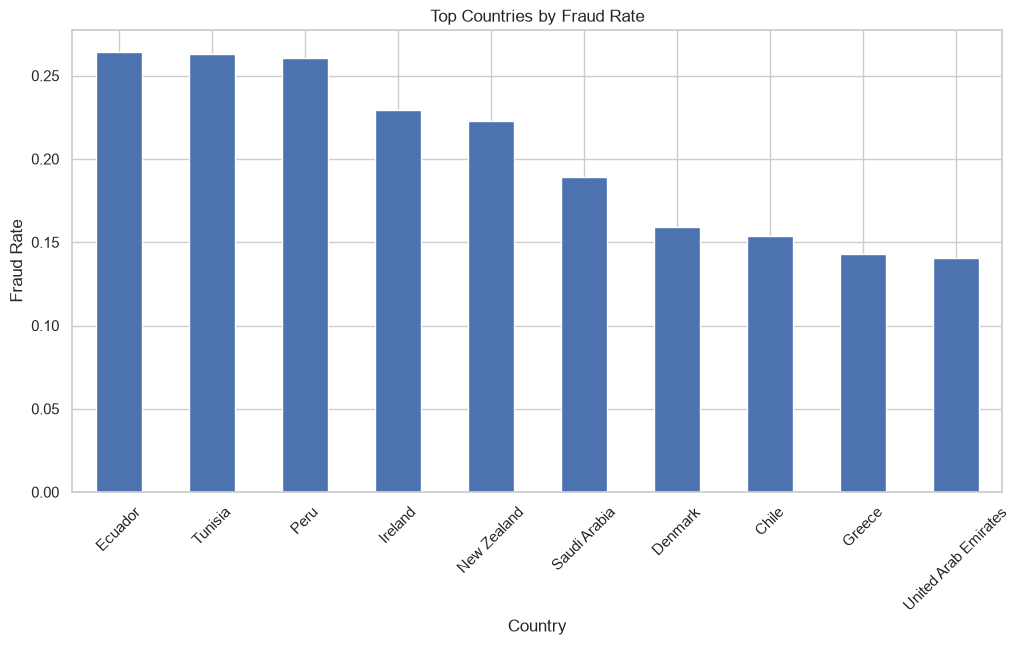

In [88]:
plt.figure(figsize=(12,6))

country_analysis_filtered.head(10)["fraud_rate"].plot(
    kind="bar"
)

plt.title(
    "Top Countries by Fraud Rate"
)

plt.xlabel(
    "Country"
)

plt.ylabel(
    "Fraud Rate"
)

plt.xticks(rotation=45)

plt.show()

In [89]:
fraud_df["signup_time"] = pd.to_datetime(
    fraud_df["signup_time"]
)

fraud_df["purchase_time"] = pd.to_datetime(
    fraud_df["purchase_time"]
)

In [90]:
fraud_df["hour_of_day"] = (
    fraud_df["purchase_time"]
    .dt.hour
)

In [91]:
fraud_df["day_of_week"] = (
    fraud_df["purchase_time"]
    .dt.day_name()
)

In [92]:
fraud_df["purchase_month"] = (
    fraud_df["purchase_time"]
    .dt.month
)

In [93]:
fraud_df["is_weekend"] = (
    fraud_df["purchase_time"]
    .dt.weekday >= 5
).astype(int)

In [94]:
fraud_df["time_since_signup"] = (
    fraud_df["purchase_time"]
    -
    fraud_df["signup_time"]
)

In [95]:
fraud_df["time_since_signup_hours"] = (
    fraud_df["time_since_signup"]
    .dt.total_seconds()
    /
    3600
)

In [96]:
fraud_df[
[
"signup_time",
"purchase_time",
"time_since_signup_hours"
]
].head()

,signup_time,purchase_time,time_since_signup_hours
0,2015-02-16 00:17:05,2015-03-08 10:00:39,489.726111
1,2015-03-08 04:03:22,2015-03-20 17:23:45,301.339722
2,2015-05-17 16:45:54,2015-05-26 08:54:34,208.144444
3,2015-03-03 19:58:39,2015-05-28 21:09:13,2065.176111
4,2015-03-20 00:31:27,2015-04-05 07:31:46,391.005278


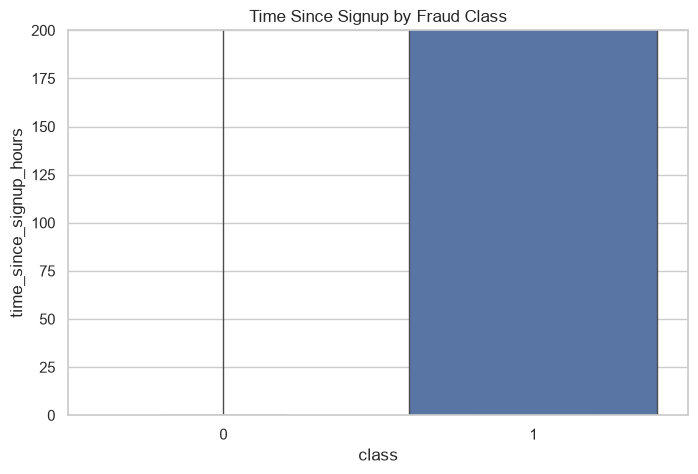

In [97]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=fraud_df,
    x="class",
    y="time_since_signup_hours"
)

plt.title(
    "Time Since Signup by Fraud Class"
)

plt.ylim(0,200)

plt.show()

In [98]:
fraud_df["user_transaction_count"] = (
    fraud_df
    .groupby("user_id")["user_id"]
    .transform("count")
)

In [99]:
fraud_df["device_transaction_count"] = (
    fraud_df
    .groupby("device_id")["device_id"]
    .transform("count")
)

In [100]:
fraud_df[
[
"user_id",
"user_transaction_count",
"device_transaction_count"
]
].head()

,user_id,user_transaction_count,device_transaction_count
0,62421,1,1
1,173212,1,1
2,242286,1,1
3,370003,1,1
4,119824,1,1


In [101]:
fraud_df.to_csv(
    "../data/processed/fraud_feature_engineered.csv",
    index=False
)

In [102]:
fraud_df.columns.tolist()

['user_id',
 'signup_time',
 'purchase_time',
 'purchase_value',
 'device_id',
 'source',
 'browser',
 'sex',
 'age',
 'ip_address',
 'class',
 'ip_address_int',
 'lower_bound_ip_address',
 'upper_bound_ip_address',
 'country',
 'hour_of_day',
 'day_of_week',
 'purchase_month',
 'is_weekend',
 'time_since_signup',
 'time_since_signup_hours',
 'user_transaction_count',
 'device_transaction_count']

In [103]:
drop_columns = [
    "user_id",
    "device_id",
    "ip_address",
    "signup_time",
    "purchase_time",
    "time_since_signup"
]

In [104]:
fraud_model_df = fraud_df.drop(
    columns=drop_columns
)

In [105]:
fraud_model_df.head()

,purchase_value,source,browser,sex,age,class,ip_address_int,lower_bound_ip_address,upper_bound_ip_address,country,hour_of_day,day_of_week,purchase_month,is_weekend,time_since_signup_hours,user_transaction_count,device_transaction_count
0,46,Direct,Safari,M,36,0,52093,NaN,NaN,Unknown,10,Sunday,3,1,489.726111,1,1
1,33,Ads,IE,F,30,0,93447,NaN,NaN,Unknown,17,Friday,3,0,301.339722,1,1
2,33,Direct,FireFox,F,32,0,105819,NaN,NaN,Unknown,8,Tuesday,5,0,208.144444,1,1
3,33,Ads,IE,M,40,0,117567,NaN,NaN,Unknown,21,Thursday,5,0,2065.176111,1,1
4,55,Ads,Safari,M,38,0,131424,NaN,NaN,Unknown,7,Sunday,4,1,391.005278,1,1


In [106]:
fraud_df = fraud_df.drop(
    columns=[
        "lower_bound_ip_address",
        "upper_bound_ip_address"
    ]
)

In [107]:
fraud_df.columns.tolist()

['user_id',
 'signup_time',
 'purchase_time',
 'purchase_value',
 'device_id',
 'source',
 'browser',
 'sex',
 'age',
 'ip_address',
 'class',
 'ip_address_int',
 'country',
 'hour_of_day',
 'day_of_week',
 'purchase_month',
 'is_weekend',
 'time_since_signup',
 'time_since_signup_hours',
 'user_transaction_count',
 'device_transaction_count']

In [108]:
drop_columns = [
    "user_id",
    "device_id",
    "ip_address",
    "signup_time",
    "purchase_time",
    "time_since_signup"
]

In [109]:
fraud_model_df = fraud_df.drop(
    columns=drop_columns,
    errors="ignore"
)

In [110]:
fraud_model_df.head()

,purchase_value,source,browser,sex,age,class,ip_address_int,country,hour_of_day,day_of_week,purchase_month,is_weekend,time_since_signup_hours,user_transaction_count,device_transaction_count
0,46,Direct,Safari,M,36,0,52093,Unknown,10,Sunday,3,1,489.726111,1,1
1,33,Ads,IE,F,30,0,93447,Unknown,17,Friday,3,0,301.339722,1,1
2,33,Direct,FireFox,F,32,0,105819,Unknown,8,Tuesday,5,0,208.144444,1,1
3,33,Ads,IE,M,40,0,117567,Unknown,21,Thursday,5,0,2065.176111,1,1
4,55,Ads,Safari,M,38,0,131424,Unknown,7,Sunday,4,1,391.005278,1,1


In [111]:
X = fraud_model_df.drop(
    "class",
    axis=1
)

y = fraud_model_df["class"]

In [112]:
X.shape, y.shape

((151112, 14), (151112,))

In [113]:
X.select_dtypes(
    include="object"
).columns

C:\Users\HP\AppData\Local\Temp\ipykernel_10736\685242778.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  X.select_dtypes(


Index(['source', 'browser', 'sex', 'country', 'day_of_week'], dtype='str')

In [114]:
categorical_cols = X.select_dtypes(
    include=["object", "str"]
).columns

In [115]:
categorical_cols

Index(['source', 'browser', 'sex', 'country', 'day_of_week'], dtype='str')

In [116]:
numerical_cols = X.select_dtypes(
    exclude=["object", "str"]
).columns

In [117]:
numerical_cols

Index(['purchase_value', 'age', 'ip_address_int', 'hour_of_day',
       'purchase_month', 'is_weekend', 'time_since_signup_hours',
       'user_transaction_count', 'device_transaction_count'],
      dtype='str')

In [118]:
from sklearn.preprocessing import OneHotEncoder

In [119]:
encoder = OneHotEncoder(
    drop="first",
    sparse_output=False,
    handle_unknown="ignore"
)

In [121]:
categorical_cols = X.select_dtypes(
    include=["object", "string"]
).columns

In [122]:
categorical_cols

Index(['source', 'browser', 'sex', 'country', 'day_of_week'], dtype='str')

In [123]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    drop="first",
    handle_unknown="ignore",
    sparse_output=False
)

In [124]:
encoded_features = encoder.fit_transform(
    X[categorical_cols]
)

In [125]:
encoded_df = pd.DataFrame(
    encoded_features,
    columns=encoder.get_feature_names_out(categorical_cols)
)

In [126]:
numerical_cols = X.select_dtypes(
    exclude="object"
).columns

In [127]:
numeric_df = X[numerical_cols].reset_index(
    drop=True
)

In [128]:
X_encoded = pd.concat(
    [
        numeric_df,
        encoded_df
    ],
    axis=1
)

In [130]:
X_encoded.head()

,purchase_value,age,ip_address_int,hour_of_day,purchase_month,is_weekend,time_since_signup_hours,user_transaction_count,device_transaction_count,source_Direct,source_SEO,browser_FireFox,browser_IE,browser_Opera,browser_Safari,sex_M,country_Albania,country_Algeria,country_Angola,country_Antigua and Barbuda,country_Argentina,country_Armenia,country_Australia,country_Austria,country_Azerbaijan,country_Bahamas,country_Bahrain,country_Bangladesh,country_Barbados,country_Belarus,country_Belgium,country_Belize,country_Benin,country_Bermuda,country_Bhutan,country_Bolivia,country_Bonaire; Sint Eustatius; Saba,country_Bosnia and Herzegowina,country_Botswana,country_Brazil,country_British Indian Ocean Territory,country_Brunei Darussalam,country_Bulgaria,country_Burkina Faso,country_Burundi,country_Cambodia,country_Cameroon,country_Canada,country_Cape Verde,country_Cayman Islands,country_Chile,country_China,country_Colombia,country_Congo,country_Congo The Democratic Republic of The,country_Costa Rica,country_Cote D'ivoire,country_Croatia (LOCAL Name: Hrvatska),country_Cuba,country_Curacao,country_Cyprus,country_Czech Republic,country_Denmark,country_Djibouti,country_Dominica,country_Dominican Republic,country_Ecuador,country_Egypt,country_El Salvador,country_Estonia,country_Ethiopia,country_European Union,country_Faroe Islands,country_Fiji,country_Finland,country_France,country_Gabon,country_Gambia,country_Georgia,country_Germany,country_Ghana,country_Gibraltar,country_Greece,country_Guadeloupe,country_Guam,country_Guatemala,country_Haiti,country_Honduras,country_Hong Kong,country_Hungary,country_Iceland,country_India,country_Indonesia,country_Iran (ISLAMIC Republic Of),country_Iraq,country_Ireland,country_Israel,country_Italy,country_Jamaica,country_Japan,country_Jordan,country_Kazakhstan,country_Kenya,country_Korea Republic of,country_Kuwait,country_Kyrgyzstan,country_Lao People's Democratic Republic,country_Latvia,country_Lebanon,country_Lesotho,country_Libyan Arab Jamahiriya,country_Liechtenstein,country_Lithuania,country_Luxembourg,country_Macau,country_Macedonia,country_Madagascar,country_Malawi,country_Malaysia,country_Maldives,country_Malta,country_Mauritius,country_Mexico,country_Moldova Republic of,country_Monaco,country_Mongolia,country_Montenegro,country_Morocco,country_Mozambique,country_Myanmar,country_Namibia,country_Nauru,country_Nepal,country_Netherlands,country_New Caledonia,country_New Zealand,country_Nicaragua,country_Niger,country_Nigeria,country_Norway,country_Oman,country_Pakistan,country_Palestinian Territory Occupied,country_Panama,country_Papua New Guinea,country_Paraguay,country_Peru,country_Philippines,country_Poland,country_Portugal,country_Puerto Rico,country_Qatar,country_Reunion,country_Romania,country_Russian Federation,country_Rwanda,country_Saint Kitts and Nevis,country_Saint Martin,country_San Marino,country_Saudi Arabia,country_Senegal,country_Serbia,country_Seychelles,country_Singapore,country_Slovakia (SLOVAK Republic),country_Slovenia,country_South Africa,country_South Sudan,country_Spain,country_Sri Lanka,country_Sudan,country_Sweden,country_Switzerland,country_Syrian Arab Republic,country_Taiwan; Republic of China (ROC),country_Tajikistan,country_Tanzania United Republic of,country_Thailand,country_Trinidad and Tobago,country_Tunisia,country_Turkey,country_Turkmenistan,country_Uganda,country_Ukraine,country_United Arab Emirates,country_United Kingdom,country_United States,country_Unknown,country_Uruguay,country_Uzbekistan,country_Vanuatu,country_Venezuela,country_Viet Nam,country_Virgin Islands (U.S.),country_Yemen,country_Zambia,country_Zimbabwe,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday
0,46,36,52093,10,3,1,489.726111,1,1,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0

In [131]:
from sklearn.preprocessing import StandardScaler

In [132]:
scaler = StandardScaler()

In [133]:
X_encoded[numerical_cols] = scaler.fit_transform(
    X_encoded[numerical_cols]
)

In [134]:
X_encoded.describe()

,purchase_value,age,ip_address_int,hour_of_day,purchase_month,is_weekend,time_since_signup_hours,user_transaction_count,device_transaction_count,source_Direct,source_SEO,browser_FireFox,browser_IE,browser_Opera,browser_Safari,sex_M,country_Albania,country_Algeria,country_Angola,country_Antigua and Barbuda,country_Argentina,country_Armenia,country_Australia,country_Austria,country_Azerbaijan,country_Bahamas,country_Bahrain,country_Bangladesh,country_Barbados,country_Belarus,country_Belgium,country_Belize,country_Benin,country_Bermuda,country_Bhutan,country_Bolivia,country_Bonaire; Sint Eustatius; Saba,country_Bosnia and Herzegowina,country_Botswana,country_Brazil,country_British Indian Ocean Territory,country_Brunei Darussalam,country_Bulgaria,country_Burkina Faso,country_Burundi,country_Cambodia,country_Cameroon,country_Canada,country_Cape Verde,country_Cayman Islands,country_Chile,country_China,country_Colombia,country_Congo,country_Congo The Democratic Republic of The,country_Costa Rica,country_Cote D'ivoire,country_Croatia (LOCAL Name: Hrvatska),country_Cuba,country_Curacao,country_Cyprus,country_Czech Republic,country_Denmark,country_Djibouti,country_Dominica,country_Dominican Republic,country_Ecuador,country_Egypt,country_El Salvador,country_Estonia,country_Ethiopia,country_European Union,country_Faroe Islands,country_Fiji,country_Finland,country_France,country_Gabon,country_Gambia,country_Georgia,country_Germany,country_Ghana,country_Gibraltar,country_Greece,country_Guadeloupe,country_Guam,country_Guatemala,country_Haiti,country_Honduras,country_Hong Kong,country_Hungary,country_Iceland,country_India,country_Indonesia,country_Iran (ISLAMIC Republic Of),country_Iraq,country_Ireland,country_Israel,country_Italy,country_Jamaica,country_Japan,country_Jordan,country_Kazakhstan,country_Kenya,country_Korea Republic of,country_Kuwait,country_Kyrgyzstan,country_Lao People's Democratic Republic,country_Latvia,country_Lebanon,country_Lesotho,country_Libyan Arab Jamahiriya,country_Liechtenstein,country_Lithuania,country_Luxembourg,country_Macau,country_Macedonia,country_Madagascar,country_Malawi,country_Malaysia,country_Maldives,country_Malta,country_Mauritius,country_Mexico,country_Moldova Republic of,country_Monaco,country_Mongolia,country_Montenegro,country_Morocco,country_Mozambique,country_Myanmar,country_Namibia,country_Nauru,country_Nepal,country_Netherlands,country_New Caledonia,country_New Zealand,country_Nicaragua,country_Niger,country_Nigeria,country_Norway,country_Oman,country_Pakistan,country_Palestinian Territory Occupied,country_Panama,country_Papua New Guinea,country_Paraguay,country_Peru,country_Philippines,country_Poland,country_Portugal,country_Puerto Rico,country_Qatar,country_Reunion,country_Romania,country_Russian Federation,country_Rwanda,country_Saint Kitts and Nevis,country_Saint Martin,country_San Marino,country_Saudi Arabia,country_Senegal,country_Serbia,country_Seychelles,country_Singapore,country_Slovakia (SLOVAK Republic),country_Slovenia,country_South Africa,country_South Sudan,country_Spain,country_Sri Lanka,country_Sudan,country_Sweden,country_Switzerland,country_Syrian Arab Republic,country_Taiwan; Republic of China (ROC),country_Tajikistan,country_Tanzania United Republic of,country_Thailand,country_Trinidad and Tobago,country_Tunisia,country_Turkey,country_Turkmenistan,country_Uganda,country_Ukraine,country_United Arab Emirates,country_United Kingdom,country_United States,country_Unknown,country_Uruguay,country_Uzbekistan,country_Vanuatu,country_Venezuela,country_Viet Nam,country_Virgin Islands (U.S.),country_Yemen,country_Zambia,country_Zimbabwe,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday
count,1.511120e+05,1.511120e+05,1.511120e+05,1.511120e+05,1.511120e+05,1.511120e+05,1.511120e+05,151112.0,1.511120e+05,151112.000000,151112.000000,151112.000000,151112.000000,151112.000000,151112.000000,151112.000000,151112.000000,1511

In [135]:
processed_df = X_encoded.copy()

processed_df["class"] = y.values

In [136]:
processed_df.to_csv(
    "../data/processed/fraud_model_ready.csv",
    index=False
)

In [137]:
import joblib

In [138]:
joblib.dump(
    encoder,
    "../models/fraud_encoder.pkl"
)

['../models/fraud_encoder.pkl']

In [139]:
joblib.dump(
    scaler,
    "../models/fraud_scaler.pkl"
)

['../models/fraud_scaler.pkl']